In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from numpy.random import choice, normal, seed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6291 entries, 2000-01-01 to 2017-03-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ozone   6167 non-null   float64
dtypes: float64(1)
memory usage: 98.3 KB
None


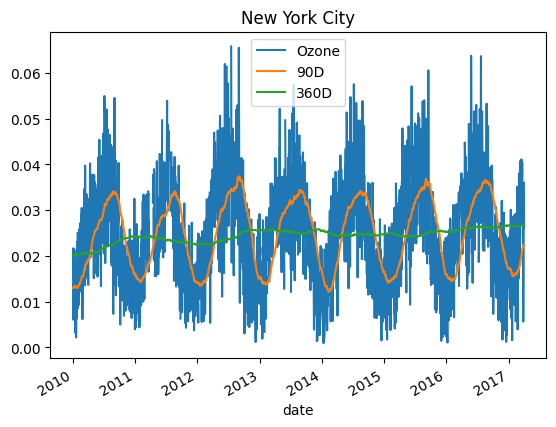

In [2]:
# Import and inspect ozone data here
data = pd.read_csv('../Data/air_quality_data/ozone_nyc.csv', parse_dates = ['date'], index_col = 'date')
print(data.info())

# Calculate 90d and 360d rolling mean for the last price
data['90D'] = data['Ozone'].rolling(window = '90D').mean()
data['360D'] = data['Ozone'].rolling(window = '360D').mean()

# Plot data
data['2010' : ].plot(title = 'New York City')
plt.show()

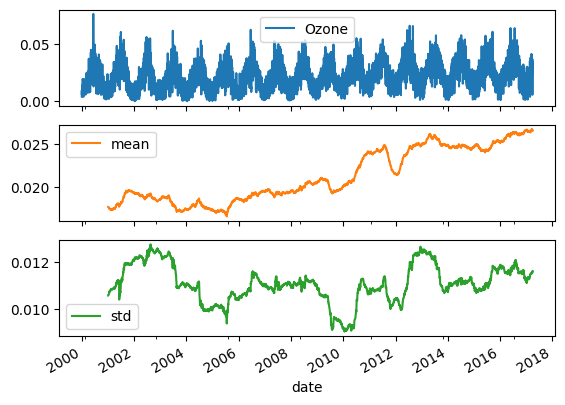

In [3]:
# Import and inspect ozone data here
data = pd.read_csv('../Data/air_quality_data/ozone_nyc.csv', parse_dates = ['date'], index_col = 'date').dropna()

# Calculate the rolling mean and std here
rolling_stats = data['Ozone'].rolling(360).agg(['mean', 'std'])

# Join rolling_stats with ozone data
stats = data.join(rolling_stats)

# Plot stats
stats.plot(subplots = True);
plt.show()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6300 entries, 2000-01-01 to 2017-03-31
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ozone   6300 non-null   float64
dtypes: float64(1)
memory usage: 98.4 KB
None


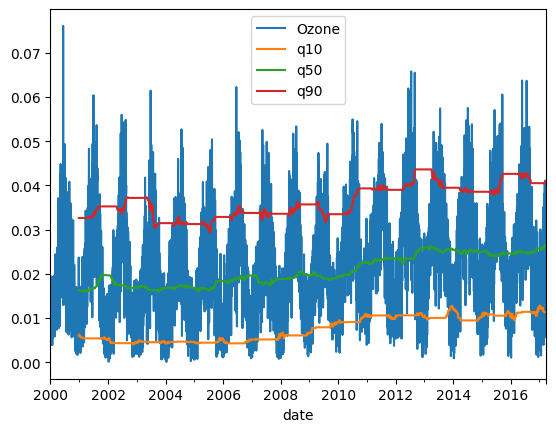

In [4]:
data = pd.read_csv('../Data/air_quality_data/ozone_nyc.csv', parse_dates = ['date'], index_col = 'date').dropna()

# Resample, interpolate and inspect ozone data here
data = data.resample('D').interpolate()
print(data.info())

# Create the rolling window
rolling = data['Ozone'].rolling(360)

# Insert the rolling quantiles to the monthly returns
data['q10'] = rolling.quantile(0.1).to_frame('q10')
data['q50'] = rolling.quantile(0.5).to_frame('q50')
data['q90'] = rolling.quantile(0.9).to_frame('q90')

# Plot the data
data.plot()
plt.show()

In [5]:
data = pd.read_csv('../Data/stock_data/google.csv', parse_dates = ['Date'], index_col = 'Date').dropna()

# Calculate differences
differences = data.diff().dropna()

# Select start price
start_price = data.head(1)
# start_price = data.first('D')

# Calculate cumulative sum
cumulative_sum = pd.concat([start_price, differences]).cumsum()

# Validate cumulative sum equals data
print(data.equals(cumulative_sum))

True


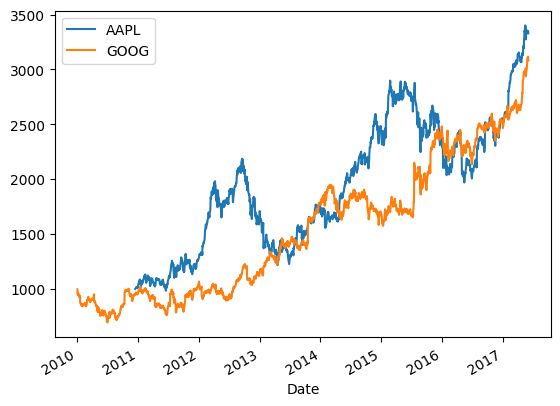

In [6]:
data = pd.read_csv('../Data/stock_data/apple_google.csv', parse_dates = ['Date'], index_col = 'Date')

# Define your investment
investment = 1000

# Calculate the daily returns here
returns = data.pct_change()

# Calculate the cumulative returns here
returns_plus_one = returns.add(1)
cumulative_return = returns_plus_one.cumprod()

# Calculate and plot the investment return here 
cumulative_return.mul(investment).plot()
plt.show()

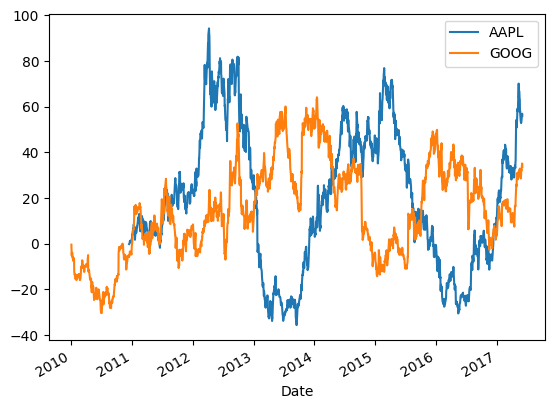

In [7]:
data = pd.read_csv('../Data/stock_data/apple_google.csv', parse_dates = ['Date'], index_col = 'Date')

# Define a multi_period_return function
def multi_period_return(period_returns):
    return np.prod(period_returns + 1) - 1
    
# Calculate daily returns
daily_returns = data.pct_change()

# Calculate rolling_annual_returns
rolling_annual_returns = daily_returns.rolling('360D').apply(multi_period_return)

# Plot rolling_annual_returns
rolling_annual_returns.mul(100).plot()
plt.show()

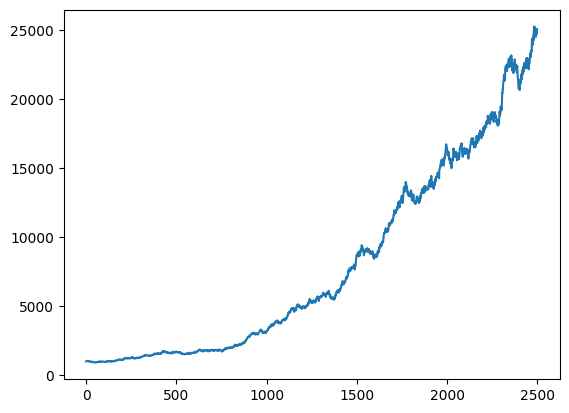

In [8]:
# Set seed here
seed(42)

# Create random_walk
random_walk = normal(loc = 0.001, scale = 0.01, size = 2500)

# Convert random_walk to pd.series
random_walk = pd.Series(random_walk)

# Create random_prices
random_prices = random_walk.add(1).cumprod()

# Plot random_prices here
random_prices.mul(1000).plot()
plt.show()

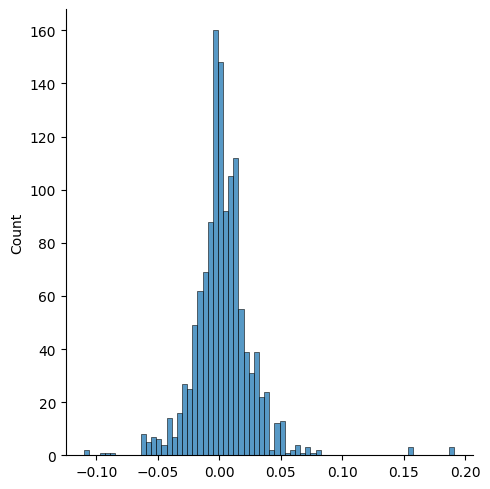

In [9]:
fb = pd.read_csv('../Data/stock_data/fb.csv', names = ['date', 'price'], parse_dates = ['date'], index_col = 'date')

# Set seed here
seed(42)

# Calculate daily_returns here
daily_returns = fb['price'].pct_change().dropna()

# Get n_obs
n_obs = daily_returns.count()

# Create random_walk
random_walk = choice(daily_returns, size = n_obs)

# Convert random_walk to pd.series
random_walk = pd.Series(random_walk)

# Plot random_walk distribution
sns.displot(random_walk)
plt.show()

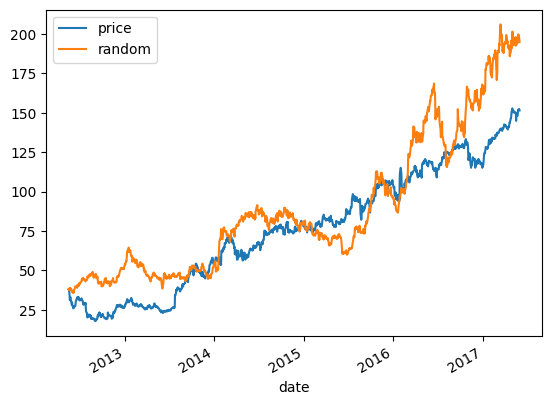

In [10]:
fb = pd.read_csv('../Data/stock_data/fb.csv', names = ['date', 'price'], parse_dates = ['date'], index_col = 'date')

# Set seed here
seed(10)

# Calculate daily_returns here
daily_returns = fb['price'].pct_change().dropna()

# Get n_obs
n_obs = daily_returns.count()

# Create random_walk
random_walk = choice(daily_returns, size = n_obs)

# Convert random_walk to pd.series
random_walk = pd.Series(random_walk)

# Select fb start price here
start = fb['price'].head(1)

# Add 1 to random walk and append to start
random_walk = random_walk.add(1)

random_price = pd.concat([start, random_walk])
random_price.index = fb.index

# Calculate cumulative product here
random_price = random_price.cumprod()

# Insert into fb and plot
fb['random'] = random_price
fb.plot()
plt.show()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4001 entries, 2001-07-05 to 2017-05-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    4000 non-null   float64
 1   AMZN    4000 non-null   float64
 2   IBM     4000 non-null   float64
 3   WMT     4000 non-null   float64
 4   XOM     4000 non-null   float64
dtypes: float64(5)
memory usage: 187.5 KB
None
          AAPL      AMZN       IBM       WMT       XOM
AAPL  1.000000  0.208731  0.460568 -0.183553  0.336413
AMZN  0.208731  1.000000  0.346407 -0.367620 -0.133965
IBM   0.460568  0.346407  1.000000  0.155445  0.367253
WMT  -0.183553 -0.367620  0.155445  1.000000  0.178833
XOM   0.336413 -0.133965  0.367253  0.178833  1.000000


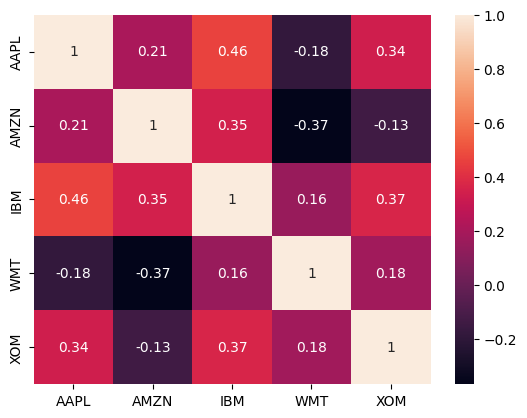

In [11]:
data = pd.read_csv('../Data/stock_data/5_stocks.csv', parse_dates = ['Date'], index_col = 'Date')

# Inspect data here
print(data.info())

# Calculate year-end prices here
annual_prices = data.resample('YE').last()

# Calculate annual returns here
annual_returns = annual_prices.pct_change()

# Calculate and print the correlation matrix here
correlations = annual_returns.corr()
print(correlations)

# Visualize the correlations as heatmap here
sns.heatmap(correlations, annot = True)
plt.show()